<a href="https://colab.research.google.com/github/scudilio/FACENS/blob/main/Aula_3___Machine_Learning__Regressao___Facens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Precificacao de Seguros de Saude

## **1. Introdução ao Projeto: Precificação de Seguros de Saúde**

Este projeto tem como objetivo principal desenvolver um modelo preditivo capaz de estimar os custos médicos individuais, um fator crucial para a precificação de seguros de saúde. Através da análise de diversas características demográficas e de saúde, buscaremos construir um **modelo de regressão** robusto que permita prever com precisão as despesas médicas, auxiliando as seguradoras a estabelecer preços justos e competitivos, bem como a gerenciar riscos de forma mais eficaz.

### Etapas do Projeto

Este projeto seguirá as seguintes etapas principais para desenvolver um modelo de precificação de seguros de saúde:

*   **Aquisição**: Coleta de dados relevantes de diversas fontes
*   **Análise Exploratória de Dados (EDA)**: Uma investigação inicial dos dados para descobrir padrões, identificar anomalias, entender as distribuições das variáveis e testar hipóteses, utilizando resumos gráficos e estatísticos.
*   **Engenharia de Features**: Criação de novas variáveis ou modificação de variáveis existentes a partir dos dados brutos para melhorar o poder preditivo dos modelos.
seguida por etapas de limpeza, tratamento de valores ausentes, remoção de duplicatas e transformação dos dados para um formato adequado para análise.
*   **Desenvolvimento e Seleção do Modelo**: Construção e treinamento de diferentes modelos de aprendizado de máquina (e.g., modelos de regressão, árvores de decisão, etc.) e seleção do melhor modelo com base em métricas de desempenho predefinidas.
*   **Avaliação do Modelo**: Validação rigorosa do desempenho do modelo em dados não vistos para garantir sua robustez e capacidade de generalização para novos dados.
*   **Aplicação e Interpretação**: Utilização do modelo final para prever os custos médicos esperados e interpretação dos resultados para informar as decisões de precificação de seguros de saúde, garantindo transparência e explicabilidade.



## **2. Coleta de Dados e organizacao setup**

In [1]:
#pip install pandas # instalando biblioteca processar dataframe

In [75]:
#importando as bibliotecas

import pandas as pd #biblioteca processar dataframe
import numpy as np #biblioteca processar array(vetores) e manipulacao algebricas
import seaborn as sns #biblioteca de visualizacao de dados
from sklearn.linear_model import LinearRegression #biblioteca de regressao linear
from sklearn.model_selection import train_test_split #biblioteca de divisao de dados
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error #biblioteca de avaliacao do modelo

In [13]:
df = pd.read_csv('insurance.csv' ) #importando o arquivo csv

In [14]:
df.head() #visualizando as 5 primeiras linhas do dataframe

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
df.dtypes #identificando os tipos de dados

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [42]:
df.shape

(1338, 8)

## 3. Analise de Exploratoria de Dados (EDA)

In [18]:
# analise descritivas

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Analise geral

idade dos clientes 39 anos com custo medio de saude de ~13mil por ano

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

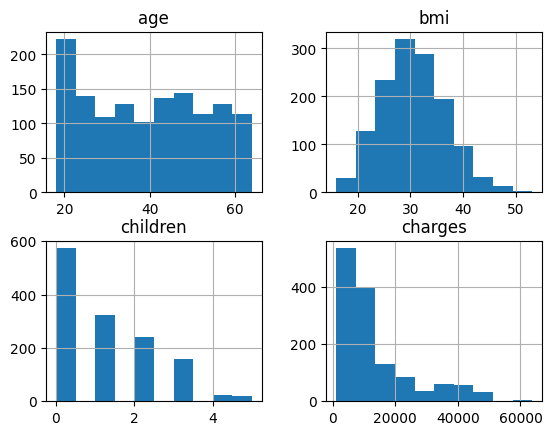

In [24]:
df.hist()

In [21]:
# Sera que mulheres gastam mais em saude do que homes?

df.groupby('sex')['charges'].mean()

,charges
sex,
female,12569.578844
male,13956.751178


In [23]:
# Pessoas que fumam gastam mais em saude?

df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8434.268298
yes,32050.231832


In [25]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0



# **3. Engenharia de Feature -Pre Processamento**


In [27]:
df['smoker_'] = df['smoker'].map({'yes':1,'no':0})


In [28]:
df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [29]:
df['charges'] = df['charges']/1000

## 4. Modelagem - Regressao Linear

In [30]:
LinearRegression()

LinearRegression()

In [44]:
y = df['charges'] # target
X = df[['bmi']] # features

In [45]:
reg = LinearRegression()
reg.fit(X,y) #treinamento

LinearRegression()

In [46]:
y_predito = reg.predict(X)
y_predito

array([12.18199477, 14.49402946, 14.19074723, ..., 15.70715839,
       11.3548614 , 12.64282621])

In [47]:
y

,charges
0,16.884924
1,1.725552
2,4.449462
3,21.984471
4,3.866855
...,...
1333,10.600548
1334,2.205981
1335,1.629833
1336,2.007945


Problema: fazendo dessa maneira eu nao consigo analisar se o modelo realmente aprendeu ou decorou as informacoes.
Para analisar a performance do modelo, preciso de metricas de avaliacao e tecnicas que consiga ver se o modelo previsao.

### **Separar a base em treino e teste**

In [51]:
X_treino,X_teste,y_treino, y_teste =  train_test_split(X,y, test_size= 0.25, random_state= 482)

In [54]:
reg = LinearRegression()

In [56]:
reg.fit(X_treino, y_treino) #treinamento do modelo

LinearRegression()

In [57]:
y_pred_treino = reg.predict(X_treino) #analisar se o modelo conseguiu aprender com as informacoes disponibilizadas

y_pred_teste = reg.predict(X_teste) #analisar a capacitade de generalizacao do modelo, se ele consegue fazer previsoes em novas observacoes (clientes)

## 5. Analise dos Resultados do Modelo

### Analise visual

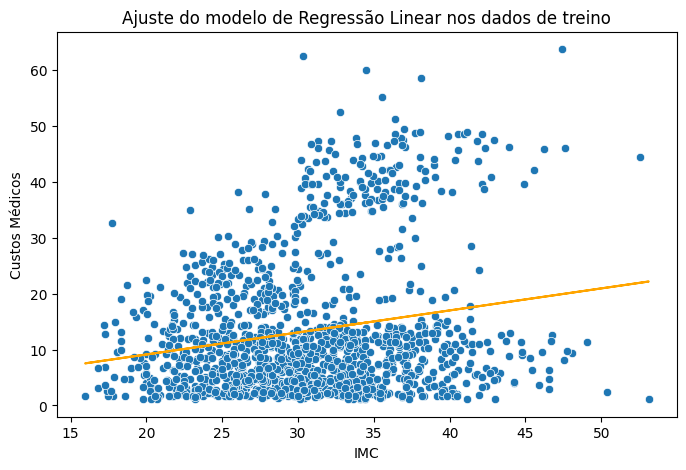

In [65]:
## Analisando o aprendizado do modelo nos dados de treino
plt.figure(figsize=(8,5))
sns.scatterplot(data = df, x ='bmi', y='charges')
plt.plot(X_treino, y_pred_treino, color='orange')
plt.title("Ajuste do modelo de Regressão Linear nos dados de treino")
plt.xlabel("IMC")
plt.ylabel("Custos Médicos")
plt.show()

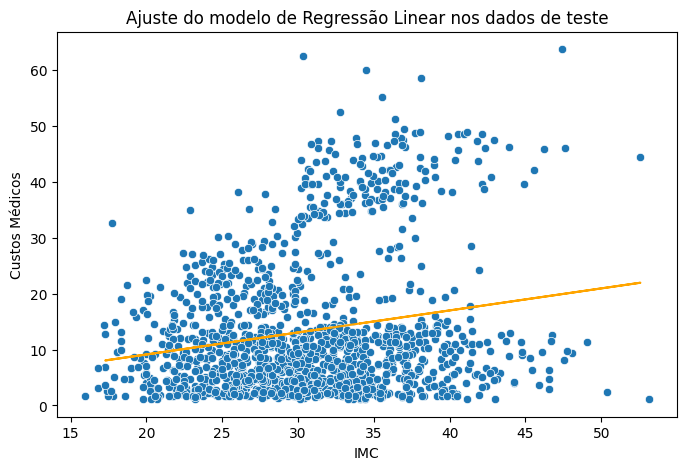

In [66]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = df, x ='bmi', y='charges')
plt.plot(X_teste, y_pred_teste, color='orange')
plt.title("Ajuste do modelo de Regressão Linear nos dados de teste")
plt.xlabel("IMC")
plt.ylabel("Custos Médicos")
plt.show()

### Metricas de avaliacao

In [71]:
sum((y_pred_treino - y_treino)*(y_pred_treino - y_treino))/len(y_treino) #mean square error

141.16607082240068

In [72]:
sum(((y_pred_treino - y_treino)*(y_pred_treino - y_treino))**(1/2))/len(y_treino) #root mean square error

9.164853548005116

In [79]:
rmse = root_mean_squared_error(y_treino, y_pred_treino)
mae = mean_absolute_error(y_treino, y_pred_treino)
r2 = r2_score(y_treino, y_pred_treino)

print('raiz do erro absoluto eh igual:', rmse )
print('erro absoluto medio eh igual:', mae )
print('coeficiente de determinacao eh igual:', r2 )

raiz do erro absoluto eh igual: 11.881332872300174
erro absoluto medio eh igual: 9.164853548005116
coeficiente de determinacao eh igual: 0.03900511926471151


In [81]:
rmse_ = root_mean_squared_error(y_teste,y_pred_teste)
mae_ = mean_absolute_error(y_teste, y_pred_teste)
r2_ = r2_score(y_teste, y_pred_teste)

print('raiz do erro absoluto eh igual:', rmse_ )
print('erro absoluto medio eh igual:', mae_ )
print('coeficiente de determinacao eh igual:', r2_ )


raiz do erro absoluto eh igual: 11.816625720692855
erro absoluto medio eh igual: 9.284687873385977
coeficiente de determinacao eh igual: 0.03911028207288125


O Modelo nao esta adequado para prever custos medicos, entao iremos adicionar mais informacoes dos clientes para ver se o modelo consegue aprender a prever custos medicos

# Versao 2 - Tentando melhorar o modelo

In [82]:
X = df[['bmi','smoker_']]
y = df['charges']

In [83]:
X_treino,X_teste,y_treino, y_teste =  train_test_split(X,y, test_size =0.25, random_state= 482)

In [85]:
X_treino

,bmi,smoker_
598,32.600,0
898,40.260,0
1189,28.000,0
531,31.730,0
1129,18.600,0
...,...,...
614,33.000,0
678,36.100,0
422,32.775,1
208,31.800,0


In [84]:
reg = LinearRegression()

In [86]:
reg.fit(X_treino, y_treino)

LinearRegression()

In [87]:
y_pred_treino = reg.predict(X_treino) # analisando se o modelo aprendeu
y_pred_teste = reg.predict(X_teste) #analisando se o modelo consegue fazer previsoes em novos clientes

In [88]:
#avaliar os resultados
rmse = root_mean_squared_error(y_treino, y_pred_treino)
mae = mean_absolute_error(y_treino, y_pred_treino)
r2 = r2_score(y_treino, y_pred_treino)

print('raiz do erro absoluto eh igual:', rmse )
print('erro absoluto medio eh igual:', mae )
print('coeficiente de determinacao eh igual:', r2 )

raiz do erro absoluto eh igual: 7.062811370656892
erro absoluto medio eh igual: 5.39738625651638
coeficiente de determinacao eh igual: 0.6604169830716047


In [89]:
rmse_ = root_mean_squared_error(y_teste,y_pred_teste)
mae_ = mean_absolute_error(y_teste, y_pred_teste)
r2_ = r2_score(y_teste, y_pred_teste)

print('raiz do erro absoluto eh igual:', rmse_ )
print('erro absoluto medio eh igual:', mae_ )
print('coeficiente de determinacao eh igual:', r2_ )


raiz do erro absoluto eh igual: 7.139904866973729
erro absoluto medio eh igual: 5.440203987962062
coeficiente de determinacao eh igual: 0.6491904263672048


Acrescentaod a variavel smoker notamos uma melhora expressiva nos resultados, o modelo conseguiu capturar melhor a variacao dos dados e reduzio o erro de 9 para 5

###  Visualizando os resultados


In [91]:

# Criar sequência de IMC
#bmi_range = np.linspace(df["bmi"].min(), d["bmi"].max(), 100)

# Criar dois cenários:
# 1) Não fumante (smoker = 0)
X_nao_fumante = np.column_stack([df['bmi'], np.zeros(len(df['bmi']))])
pred_nao_fumante = reg.predict(X_nao_fumante)

# 2) Fumante (smoker = 1)
X_fumante = np.column_stack([df['bmi'], np.ones(len(df['bmi']))])
pred_fumante = reg.predict(X_fumante)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


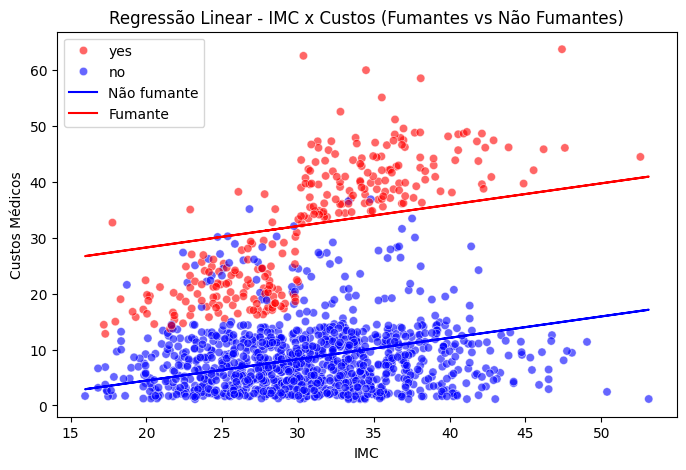

In [99]:

# Plotar dispersão
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette={'no': "blue", 'yes': "red"},
 alpha=0.6)

# Plotar retas
plt.plot(df['bmi'], pred_nao_fumante, color="blue", label="Não fumante")
plt.plot(df['bmi'], pred_fumante, color="red", label="Fumante")

plt.title("Regressão Linear - IMC x Custos (Fumantes vs Não Fumantes)")
plt.xlabel("IMC")
plt.ylabel("Custos Médicos")
plt.legend()
plt.show()

<Axes: xlabel='bmi', ylabel='charges'>

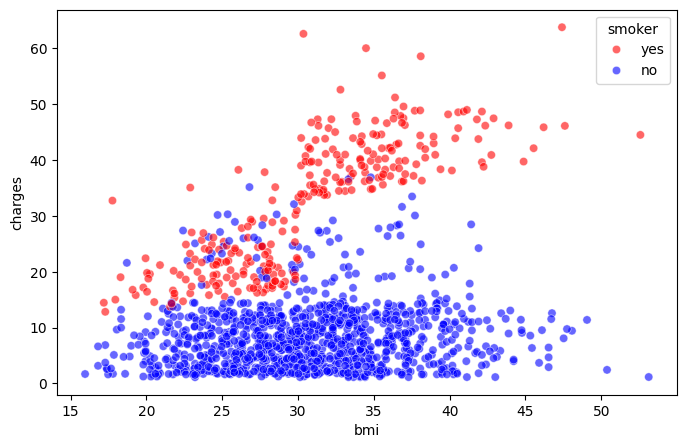

In [155]:
# Plotar dispersão
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette={'no': "blue", 'yes': "red"},
 alpha=0.6)

## Acrescentando mais informacao

In [100]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'smoker_'],
      dtype='object')

In [101]:
X = df[['bmi','smoker_', 'age','children']]
y = df['charges']

In [102]:
X_treino,X_teste,y_treino, y_teste =  train_test_split(X,y, test_size =0.25,random_state= 482)

In [103]:
reg = LinearRegression()

In [104]:
reg.fit(X_treino, y_treino)

LinearRegression()

In [105]:
y_pred_teste = reg.predict(X_teste)
y_pred_treino = reg.predict(X_treino)

In [106]:
rmse = root_mean_squared_error(y_treino, y_pred_treino)
mae = mean_absolute_error(y_treino, y_pred_treino)
r2 = r2_score(y_treino, y_pred_treino)

print('raiz do erro absoluto eh igual:', rmse )
print('erro absoluto medio eh igual:', mae )
print('coeficiente de determinacao eh igual:', r2 )

raiz do erro absoluto eh igual: 6.031798779005202
erro absoluto medio eh igual: 4.166496396323504
coeficiente de determinacao eh igual: 0.7523237078805756


In [107]:
rmse_ = root_mean_squared_error(y_teste,y_pred_teste)
mae_ = mean_absolute_error(y_teste, y_pred_teste)
r2_ = r2_score(y_teste, y_pred_teste)

print('raiz do erro absoluto eh igual:', rmse_ )
print('erro absoluto medio eh igual:', mae_ )
print('coeficiente de determinacao eh igual:', r2_ )

raiz do erro absoluto eh igual: 6.134637195420374
erro absoluto medio eh igual: 4.214706095340868
coeficiente de determinacao eh igual: 0.7410211170170962


## Fazendo novas previsoes


In [154]:
# receber as informacoes do usuario

age = float(input("Digite a sua idade:"))
peso = float(input("Digite o seu peso:"))
altura = float(input("Digite a sua altura:"))
children = int(input("Quantos  filhos voce tem?"))
smoke = input("Voce fuma? (Sim/Nao)")

bmi = peso/altura**2

smoke_ = smoke.strip().lower()

if smoke_ in ["sim", "s",'Sim', "yes", "y", "1"]:
    smoke_ = 1
elif smoke_ in ["nao", "não",'Nao', 'Não' "n", "no", "0"]:
    smoke_ = 0
else:
    print("Valor inválido. Digite sim ou não.")

KeyboardInterrupt: Interrupted by user

In [ ]:
novo_cliente = pd.DataFrame({'bmi': [bmi],
                             'smoker_': [smoke_],
                             'age': [age],
                             'children': [children], })

In [ ]:
novo_cliente

In [ ]:
custo_medico = reg.predict(novo_cliente)*1000

In [ ]:
custo_operacional = custo_medico*1.01

In [ ]:
custo_total = custo_medico + custo_operacional
margem = 0.05  # 20%

preco_total = custo_total / (1 - margem)
preco_mensal = preco_total / 12
lucro = preco - custo_total

print(custo_medico, preco_total, preco_mensal, lucro)

In [ ]:
preco

In [ ]:
preco_final = custo_medico + custo_operacionais +lucro

In [ ]:
def valor_convenio(margem_lucro=0.1, margem_custo=0.02):

    # ==========================
    # 1️⃣ Receber informações
    # ==========================
    age = float(input("Digite a sua idade: "))
    peso = float(input("Digite o seu peso (kg): "))
    altura = float(input("Digite a sua altura (m): "))
    children = int(input("Quantos filhos você tem? "))
    smoke = input("Você fuma? (Sim/Não): ")

    # ==========================
    # 2️⃣ Calcular BMI
    # ==========================
    bmi = peso / (altura ** 2)

    # ==========================
    # 3️⃣ Converter fumante
    # ==========================
    smoke_ = smoke.strip().lower()

    if smoke_ in ["sim", "s", "yes", "y", "1"]:
        smoke_ = 1
    elif smoke_ in ["nao", "não", "n", "no", "0"]:
        smoke_ = 0
    else:
        print("Valor inválido para fumante. Considerando como Não.")
        smoke_ = 0

    # ==========================
    # 4️⃣ Criar DataFrame
    # ==========================
    novo_cliente = pd.DataFrame({

        "bmi": [bmi],
        "smoker_": [smoke_],
        "age": [age],
        "children": [children]
    })

    # ==========================
    # 5️⃣ Fazer previsão
    # ==========================
    custo_medico = reg.predict(novo_cliente)[0]  # pegar valor do array

    # ==========================
    # 6️⃣ Calcular custos e preço
    # ==========================
    custo_operacional = custo_medico * margem_custo
    custo_total = custo_medico + custo_operacional

    preco_total = custo_total / (1 - margem_lucro)*1000
    preco_mensal = preco_total / 12 *1000

    lucro = preco_total - custo_total

    # ==========================
    # 7️⃣ Mostrar resultados
    # ==========================
    print("\n===== RESULTADO =====")
    print(f"Custo médico previsto: R$ {custo_medico:,.2f}")
    print(f"Custo total (com operacional): R$ {custo_total:,.2f}")
    print(f"Preço anual do plano: R$ {preco_total:,.2f}")
    print(f"Preço mensal do plano: R$ {preco_mensal:,.2f}")
    print(f"Lucro esperado: R$ {lucro:,.2f}")


    return  #{
    #     # "custo_medico": custo_medico,
    #     # "custo_total": custo_total,
    #     # "preco_anual": preco_total,
    #     # "preco_mensal": preco_mensal,
    #     # "lucro": lucro
    # }


In [ ]:
valor_convenio()
